# Normalizing Flows con PyTorch y Zuko

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana05_NFs.ipynb)

En esta notebook vamos a construir una introduccion a los **Normalizing Flows (NF)**.


Vamos a cubrir:

- el cambio de variable y la idea general de un flow;
- un flow con **affine coupling layer** tipo **RealNVP** implementado en PyTorch;
- un **MAF** y un **IAF**, con comparacion conceptual y computacional;
- un **Continuous Normalizing Flow (CNF)**;
- bloques equivalentes usando **zuko** para comparar con una libreria especializada.

## Librerias necesarias

Esta notebook usa `torch`, `matplotlib` y `zuko`.

Si hace falta, se pueden instalar asi:

```python
# CPU
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
# !pip install zuko torchdiffeq
```

`zuko` ya trae implementaciones listas de varios flows, incluyendo coupling flows, `MAF` y `CNF`.

In [21]:
import math
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import zuko
except ImportError as exc:
    raise ImportError(
        "No se pudo importar zuko. Instalar con `pip install zuko torchdiffeq`."
    ) from exc

SEED = 70
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)
print("Torch:", torch.__version__)
print("Zuko:", getattr(zuko, "__version__", "version no disponible"))

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

Dispositivo: cpu
Torch: 2.5.1
Zuko: 1.4.1


## Parte 1

### Idea central: cambio de variable

Un normalizing flow parte de una distribucion simple $p_Z(z)$ y aprende una transformacion invertible $x = f(z)$.

Si $f$ es biyectiva y diferenciable, entonces la densidad sobre $x$ se obtiene con el cambio de variable:

$$
p_X(x) = p_Z(f^{-1}(x))\left|\det \frac{\partial f^{-1}(x)}{\partial x}\right|.
$$

En logaritmos:

$$
\log p_X(x) = \log p_Z(z) + \log \left|\det \frac{\partial z}{\partial x}\right|,
\qquad z = f^{-1}(x).
$$

Entonces un flow necesita dos cosas:

1. una forma simple de **invertir** la transformacion;
2. una forma simple de calcular el **log-determinante del jacobiano**.

Las arquitecturas mas usadas fuerzan estructuras especiales del jacobiano:

- **coupling layers**: solo parte del vector se transforma en cada capa;
- **autoregressive flows**: la transformacion queda triangular;
- **continuous flows**: la transformacion se describe con una ODE.

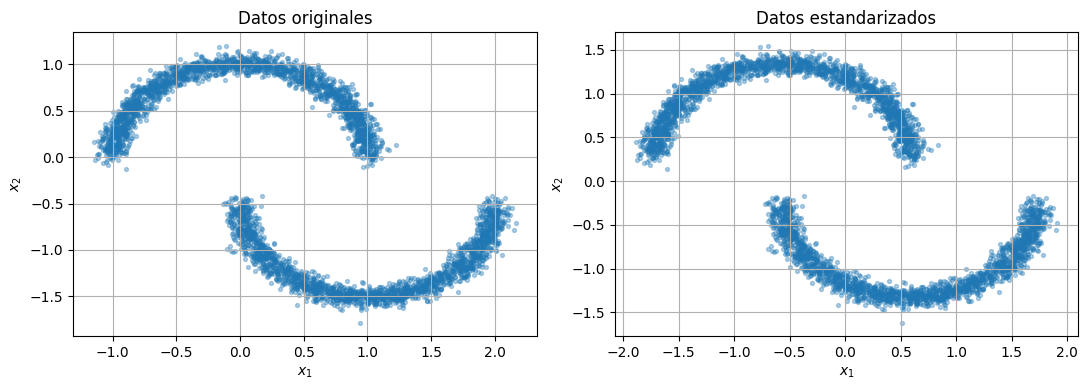

In [34]:
def sample_two_moons(n_samples=4000, noise=0.06, device=DEVICE):
    n1 = n_samples // 2
    n2 = n_samples - n1

    theta1 = torch.rand(n1, device=device) * math.pi
    theta2 = torch.rand(n2, device=device) * math.pi

    moon1 = torch.stack([torch.cos(theta1), torch.sin(theta1)], dim=1)
    moon2 = torch.stack([1.0 - torch.cos(theta2), -torch.sin(theta2) - 0.5], dim=1)

    x = torch.cat([moon1, moon2], dim=0)
    x = x + noise * torch.randn_like(x)

    perm = torch.randperm(x.size(0), device=device)
    return x[perm]


# clase auxilizar para estandarizar y desestandarizar
class Standardizer:
    def __init__(self, mean: torch.Tensor, std: torch.Tensor):
        self.mean = mean
        self.std = std

    def encode(self, x):
        return (x - self.mean) / self.std

    def decode(self, x):
        return x * self.std + self.mean


def make_standardizer(x):
    mean = x.mean(0, keepdim=True)
    std = x.std(0, keepdim=True).clamp_min(1e-4)
    return Standardizer(mean=mean, std=std)


def scatter_2d(x, ax=None, title="", alpha=0.35, s=8, color="#1f77b4"):
    if ax is None:
        _, ax = plt.subplots()
    x = x.detach().cpu()
    ax.scatter(x[:, 0], x[:, 1], s=s, alpha=alpha, color=color)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    return ax


raw_data = sample_two_moons()
standardizer = make_standardizer(raw_data)
train_data = standardizer.encode(raw_data)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
scatter_2d(raw_data, ax=axes[0], title="Datos originales")
scatter_2d(train_data, ax=axes[1], title="Datos estandarizados")
plt.tight_layout()
plt.show()

Trabajaremos con este dataset 2D porque permite ver con claridad si el flow aprende una distribucion **no gaussiana** y con geometria curva.

Procedemos a armar las clases necesarias para armar nuestros NFs.

In [ ]:
class MLP(nn.Module):
    def __init__(self, in_features, out_features, hidden_features=(64, 64), activation=nn.ReLU):
        super().__init__()
        dims = [in_features, *hidden_features, out_features]
        layers = []
        for din, dout in zip(dims[:-2], dims[1:-1]):
            layers.append(nn.Linear(din, dout))
            layers.append(activation())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class ReversePermutation(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.features = features

    def z_to_x(self, z):
        return z.flip(-1), torch.zeros(z.size(0), device=z.device)

    def x_to_z(self, x):
        return x.flip(-1), torch.zeros(x.size(0), device=x.device)


class FlowModel(nn.Module):
    def __init__(self, features, layers):
        super().__init__()
        self.features = features
        self.layers = nn.ModuleList(layers)
        self.base = torch.distributions.Independent(
            torch.distributions.Normal(
                loc=torch.zeros(features),
                scale=torch.ones(features),
            ),
            1,
        )

    def base_log_prob(self, z):
        base = self.base
        if z.device.type != "cpu":
            base = torch.distributions.Independent(
                torch.distributions.Normal(
                    loc=torch.zeros(self.features, device=z.device),
                    scale=torch.ones(self.features, device=z.device),
                ),
                1,
            )
        return base.log_prob(z)

    def sample_base(self, n, device):
        return torch.randn(n, self.features, device=device)

    def z_to_x(self, z):
        x = z
        log_det = torch.zeros(z.size(0), device=z.device)
        for layer in self.layers:
            x, ld = layer.z_to_x(x)
            log_det = log_det + ld
        return x, log_det

    def x_to_z(self, x):
        z = x
        log_det = torch.zeros(x.size(0), device=x.device)
        for layer in reversed(self.layers):
            z, ld = layer.x_to_z(z)
            log_det = log_det + ld
        return z, log_det

    def log_prob(self, x):
        z, log_det = self.x_to_z(x)
        return self.base_log_prob(z) + log_det

    @torch.no_grad()
    def sample(self, n):
        z = self.sample_base(n, next(self.parameters()).device)
        x, _ = self.z_to_x(z)
        return x


def train_density_model(model, data, epochs=350, batch_size=256, lr=1e-3, verbose_every=50):
    model = model.to(DEVICE)
    data = data.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        perm = torch.randperm(data.size(0), device=data.device)
        total = 0.0

        for i in range(0, data.size(0), batch_size):
            idx = perm[i : i + batch_size]
            batch = data[idx]
            loss = -model.log_prob(batch).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total += loss.item() * batch.size(0)

        mean_loss = total / data.size(0)
        history.append(mean_loss)
        if epoch % verbose_every == 0 or epoch == 1:
            print(f"epoch={epoch:4d}  nll={mean_loss:.4f}")

    return history


def train_zuko_flow(flow, data, epochs=350, batch_size=256, lr=1e-3, verbose_every=50):
    flow = flow.to(DEVICE)
    data = data.to(DEVICE)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        perm = torch.randperm(data.size(0), device=data.device)
        total = 0.0

        for i in range(0, data.size(0), batch_size):
            idx = perm[i : i + batch_size]
            batch = data[idx]
            dist = flow()
            loss = -dist.log_prob(batch).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total += loss.item() * batch.size(0)

        mean_loss = total / data.size(0)
        history.append(mean_loss)
        if epoch % verbose_every == 0 or epoch == 1:
            print(f"epoch={epoch:4d}  nll={mean_loss:.4f}")

    return history


def compare_samples(reference, generated, title_left="Datos", title_right="Muestras"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    scatter_2d(reference, ax=axes[0], title=title_left, color="#1f77b4")
    scatter_2d(generated, ax=axes[1], title=title_right, color="#d62728")
    plt.tight_layout()
    plt.show()


def plot_history(history, title="Curva de entrenamiento"):
    plt.figure(figsize=(6, 4))
    plt.plot(history)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("NLL media")
    plt.show()
    

#### Affine Coupling: RealNVP

En una **coupling layer** se divide el vector en dos partes:

- una parte queda igual;
- la otra se transforma usando parametros que dependen de la primera.

En una version afine:

$$
x_A = z_A,
\qquad
x_B = z_B \odot \exp(s(z_A)) + t(z_A).
$$

Ventajas:

- la inversa es inmediata;
- el jacobiano es triangular;
- el costo de `log_prob` y `sample` es similar.

Limitacion:

- cada capa solo modifica una parte de las variables, asi que suele necesitar **varias capas y permutaciones**.

epoch=   1  nll=2.5583
epoch=  50  nll=1.2363
epoch= 100  nll=1.2018
epoch= 150  nll=1.1495
epoch= 200  nll=1.1198
epoch= 250  nll=1.0915
epoch= 300  nll=1.1333
epoch= 350  nll=1.0775
epoch= 400  nll=1.1108
epoch= 450  nll=1.0601
epoch= 500  nll=1.0479


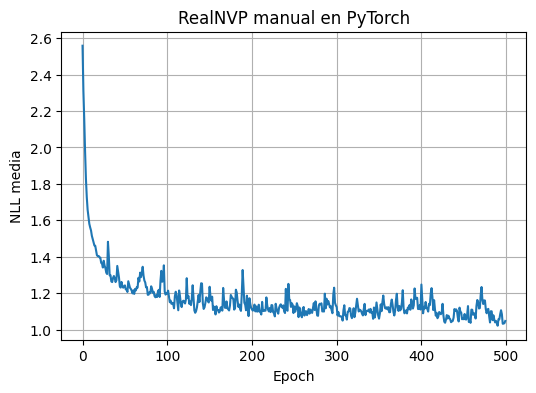

In [31]:
class AffineCoupling(nn.Module):
    def __init__(self, features, mask, hidden_features=(64, 64)):
        super().__init__()
        mask = torch.as_tensor(mask, dtype=torch.bool)
        if mask.numel() != features:
            raise ValueError("La mascara debe tener longitud `features`.")
        if mask.sum() == 0 or (~mask).sum() == 0:
            raise ValueError("La mascara debe dejar parte fija y parte transformada.")

        self.features = features
        self.register_buffer("mask", mask)
        self.cond_idx = mask
        self.trans_idx = ~mask
        self.net = MLP(int(mask.sum().item()), 2 * int((~mask).sum().item()), hidden_features)

    def _params(self, x_cond):
        shift, log_scale = self.net(x_cond).chunk(2, dim=-1)
        log_scale = 0.8 * torch.tanh(log_scale)
        return shift, log_scale

    def z_to_x(self, z):
        x = z.clone()
        z_cond = z[:, self.cond_idx]
        z_trans = z[:, self.trans_idx]
        shift, log_scale = self._params(z_cond)
        x[:, self.trans_idx] = z_trans * torch.exp(log_scale) + shift
        return x, log_scale.sum(dim=-1)

    def x_to_z(self, x):
        z = x.clone()
        x_cond = x[:, self.cond_idx]
        x_trans = x[:, self.trans_idx]
        shift, log_scale = self._params(x_cond)
        z[:, self.trans_idx] = (x_trans - shift) * torch.exp(-log_scale)
        return z, -log_scale.sum(dim=-1)


realnvp = FlowModel(
    features=2,
    layers=[
        AffineCoupling(2, mask=[1, 0], hidden_features=(64, 64)),
        AffineCoupling(2, mask=[0, 1], hidden_features=(64, 64)),
        AffineCoupling(2, mask=[1, 0], hidden_features=(64, 64)),
        AffineCoupling(2, mask=[0, 1], hidden_features=(64, 64)),
    ],
)

history_realnvp = train_density_model(realnvp, train_data, epochs=500, batch_size=128, lr=5e-4, verbose_every=50)
plot_history(history_realnvp, "RealNVP manual en PyTorch")

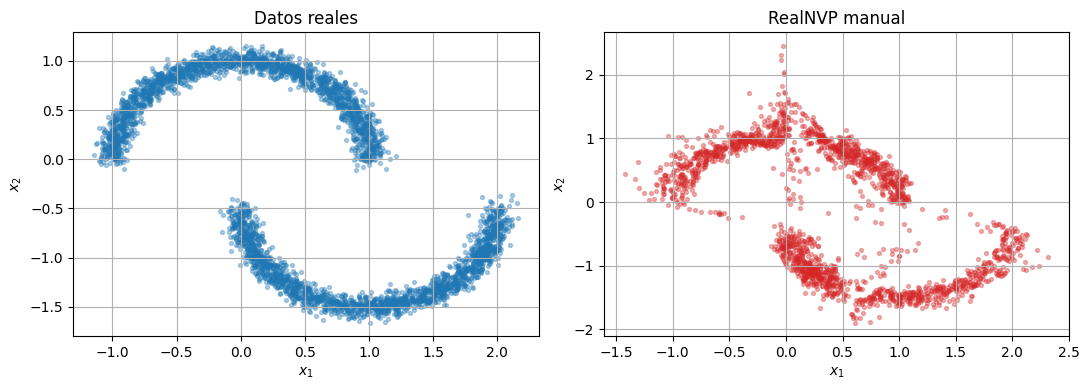

In [32]:
with torch.no_grad():
    realnvp_samples = standardizer.decode(realnvp.sample(2000).cpu())

compare_samples(raw_data.cpu(), realnvp_samples, title_left="Datos reales", title_right="RealNVP manual")

#### La misma idea usando `zuko`

En `zuko` existen flows de coupling prearmados. Segun la version instalada, puede aparecer `RealNVP` o una variante basada en coupling afine como `NICE`.

epoch=   1  nll=2.5583
epoch=  50  nll=1.2097
epoch= 100  nll=0.8744
epoch= 150  nll=0.8072
epoch= 200  nll=0.7780
epoch= 250  nll=0.8492


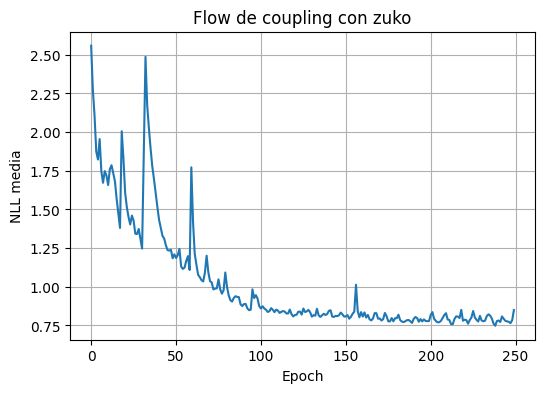

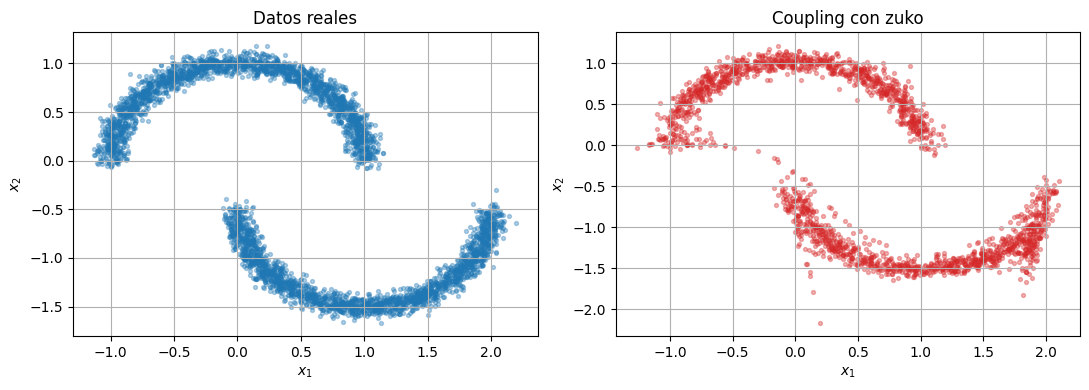

In [6]:
def make_zuko_coupling(features=2, transforms=4, hidden_features=(64, 64)):
    if hasattr(zuko.flows, "RealNVP"):
        return zuko.flows.RealNVP(
            features=features,
            transforms=transforms,
            hidden_features=hidden_features,
        )
    return zuko.flows.NICE(
        features=features,
        transforms=transforms,
        hidden_features=hidden_features,
    )


zuko_coupling = make_zuko_coupling()
history_zuko_coupling = train_zuko_flow(
    zuko_coupling,
    train_data,
    epochs=250,
    lr=1e-3,
    verbose_every=50,
)
plot_history(history_zuko_coupling, "Flow de coupling con zuko")

with torch.no_grad():
    zuko_coupling_samples = standardizer.decode(zuko_coupling().sample((2000,)).cpu())

compare_samples(raw_data.cpu(), zuko_coupling_samples, title_left="Datos reales", title_right="Coupling con zuko")

## Parte 2
### MAF vs IAF

Tanto **MAF** como **IAF** son flows autoregresivos. La diferencia esta en **que direccion** usa la parametrizacion autoregresiva.

#### MAF

$$
z_i = \frac{x_i - \mu_i(x_{<i})}{\sigma_i(x_{<i})}
$$

- evaluar `log_prob(x)` es natural y rapido;
- muestrear requiere resolver las componentes una por una.

#### IAF

$$
x_i = \mu_i(z_{<i}) + \sigma_i(z_{<i}) z_i
$$

- muestrear es natural y rapido;
- evaluar `log_prob(x)` requiere invertir secuencialmente.

En alta dimension, ese intercambio importa mucho:

- **MAF** se usa mucho para **density estimation**;
- **IAF** se usa mucho para **amortized variational inference**, donde interesa samplear rapido.

In [7]:
class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features, mask):
        super().__init__(in_features, out_features)
        self.register_buffer("mask", mask)

    def forward(self, x):
        return F.linear(x, self.weight * self.mask, self.bias)


class MADE(nn.Module):
    def __init__(self, features, hidden_features=(64, 64), out_multiplier=2):
        super().__init__()
        if features < 2:
            raise ValueError("Para esta demo usamos features >= 2.")

        input_degrees = torch.arange(1, features + 1)
        hidden_degrees = []
        for width in hidden_features:
            deg = torch.arange(width) % (features - 1) + 1
            hidden_degrees.append(deg)

        layers = []
        prev_features = features
        prev_degrees = input_degrees

        for width, deg in zip(hidden_features, hidden_degrees):
            mask = (deg[:, None] >= prev_degrees[None, :]).float()
            layers.append(MaskedLinear(prev_features, width, mask))
            layers.append(nn.ReLU())
            prev_features = width
            prev_degrees = deg

        out_degrees = input_degrees.repeat(out_multiplier)
        out_mask = (out_degrees[:, None] > prev_degrees[None, :]).float()
        layers.append(MaskedLinear(prev_features, features * out_multiplier, out_mask))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class MAFBlock(nn.Module):
    def __init__(self, features, hidden_features=(64, 64)):
        super().__init__()
        self.features = features
        self.net = MADE(features, hidden_features=hidden_features, out_multiplier=2)

    def _params(self, x):
        shift, log_scale = self.net(x).chunk(2, dim=-1)
        log_scale = 0.6 * torch.tanh(log_scale)
        return shift, log_scale

    def x_to_z(self, x):
        shift, log_scale = self._params(x)
        z = (x - shift) * torch.exp(-log_scale)
        return z, -log_scale.sum(dim=-1)

    def z_to_x(self, z):
        x = torch.zeros_like(z)
        log_det = torch.zeros(z.size(0), device=z.device)
        for i in range(self.features):
            shift, log_scale = self._params(x)
            # Evitamos una actualizacion inplace para no romper autograd.
            x = x.clone()
            x[:, i] = z[:, i] * torch.exp(log_scale[:, i]) + shift[:, i]
            log_det = log_det + log_scale[:, i]
        return x, log_det


class IAFBlock(nn.Module):
    def __init__(self, features, hidden_features=(64, 64)):
        super().__init__()
        self.features = features
        self.net = MADE(features, hidden_features=hidden_features, out_multiplier=2)

    def _params(self, z):
        shift, log_scale = self.net(z).chunk(2, dim=-1)
        log_scale = 0.6 * torch.tanh(log_scale)
        return shift, log_scale

    def z_to_x(self, z):
        shift, log_scale = self._params(z)
        x = z * torch.exp(log_scale) + shift
        return x, log_scale.sum(dim=-1)

    def x_to_z(self, x):
        z = torch.zeros_like(x)
        log_det = torch.zeros(x.size(0), device=x.device)
        for i in range(self.features):
            shift, log_scale = self._params(z)
            # Evitamos una actualizacion inplace para no romper autograd.
            z = z.clone()
            z[:, i] = (x[:, i] - shift[:, i]) * torch.exp(-log_scale[:, i])
            log_det = log_det - log_scale[:, i]
        return z, log_det

epoch=   1  nll=2.7719
epoch=  50  nll=1.0118
epoch= 100  nll=0.9170
epoch= 150  nll=0.8655
epoch= 200  nll=0.8095
epoch= 250  nll=0.8084
epoch=   1  nll=2.6495
epoch=  50  nll=0.9380
epoch= 100  nll=0.8408
epoch= 150  nll=0.8134
epoch= 200  nll=0.8151
epoch= 250  nll=0.7890


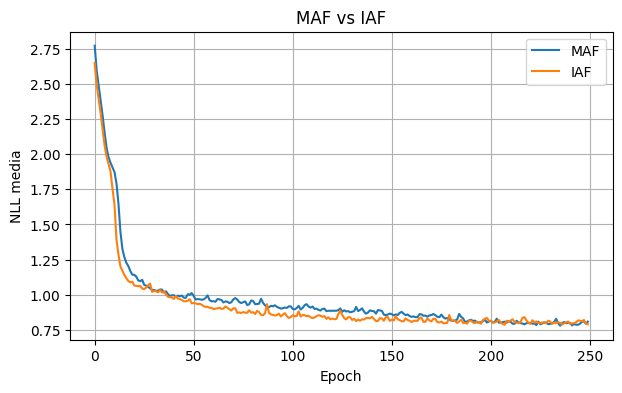

In [8]:
maf = FlowModel(
    features=2,
    layers=[
        MAFBlock(2, hidden_features=(64, 64)),
        ReversePermutation(2),
        MAFBlock(2, hidden_features=(64, 64)),
        ReversePermutation(2),
        MAFBlock(2, hidden_features=(64, 64)),
    ],
)

iaf = FlowModel(
    features=2,
    layers=[
        IAFBlock(2, hidden_features=(64, 64)),
        ReversePermutation(2),
        IAFBlock(2, hidden_features=(64, 64)),
        ReversePermutation(2),
        IAFBlock(2, hidden_features=(64, 64)),
    ],
)

history_maf = train_density_model(maf, train_data, epochs=250, lr=1e-3, verbose_every=50)
history_iaf = train_density_model(iaf, train_data, epochs=250, lr=1e-3, verbose_every=50)

plt.figure(figsize=(7, 4))
plt.plot(history_maf, label="MAF")
plt.plot(history_iaf, label="IAF")
plt.title("MAF vs IAF")
plt.xlabel("Epoch")
plt.ylabel("NLL media")
plt.legend()
plt.show()

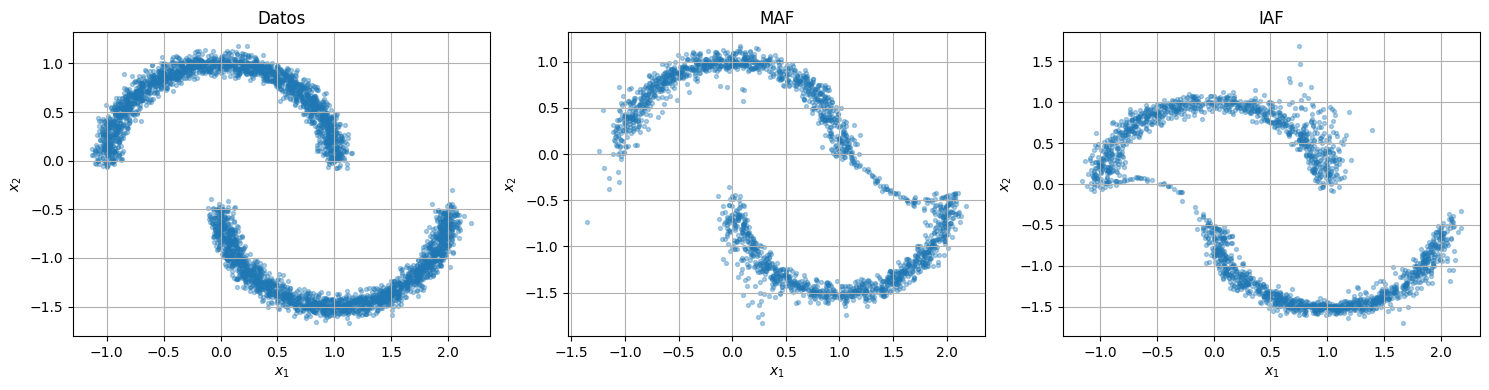

In [9]:
with torch.no_grad():
    maf_samples = standardizer.decode(maf.sample(2000).cpu())
    iaf_samples = standardizer.decode(iaf.sample(2000).cpu())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
scatter_2d(raw_data.cpu(), ax=axes[0], title="Datos")
scatter_2d(maf_samples, ax=axes[1], title="MAF")
scatter_2d(iaf_samples, ax=axes[2], title="IAF")
plt.tight_layout()
plt.show()

### Benchmark conceptual: quien gana al samplear y quien gana al evaluar densidad

En 2D la diferencia puede ser pequena. Para verla mejor, hacemos un micro-benchmark con `16` dimensiones y pesos aleatorios. No nos interesa la calidad del ajuste sino el **costo computacional de cada direccion**.

In [10]:
def benchmark_model(model, features=16, batch=1024, repeats=40):
    model = model.to(DEVICE)
    x = torch.randn(batch, features, device=DEVICE)

    with torch.no_grad():
        _ = model.log_prob(x)
        _ = model.sample(batch)

        t0 = time.perf_counter()
        for _ in range(repeats):
            _ = model.log_prob(x)
        t_logprob = time.perf_counter() - t0

        t0 = time.perf_counter()
        for _ in range(repeats):
            _ = model.sample(batch)
        t_sample = time.perf_counter() - t0

    return t_logprob, t_sample


maf16 = FlowModel(
    features=16,
    layers=[MAFBlock(16, hidden_features=(128, 128)), ReversePermutation(16), MAFBlock(16, hidden_features=(128, 128))],
)
iaf16 = FlowModel(
    features=16,
    layers=[IAFBlock(16, hidden_features=(128, 128)), ReversePermutation(16), IAFBlock(16, hidden_features=(128, 128))],
)

maf_logprob, maf_sample = benchmark_model(maf16, features=16)
iaf_logprob, iaf_sample = benchmark_model(iaf16, features=16)

print(f"MAF  -> log_prob: {maf_logprob:.3f}s   sample: {maf_sample:.3f}s")
print(f"IAF  -> log_prob: {iaf_logprob:.3f}s   sample: {iaf_sample:.3f}s")

MAF  -> log_prob: 0.030s   sample: 0.710s
IAF  -> log_prob: 0.577s   sample: 0.049s


Lo que deberiamos observar es:

- **MAF**: `log_prob` relativamente rapido y `sample` mas caro.
- **IAF**: `sample` relativamente rapido y `log_prob` mas caro.

Esa es la diferencia estructural importante entre ambos.

epoch=   1  nll=2.6316
epoch=  50  nll=0.8634
epoch= 100  nll=0.7873
epoch= 150  nll=0.7501
epoch= 200  nll=0.7751
epoch= 250  nll=0.7413


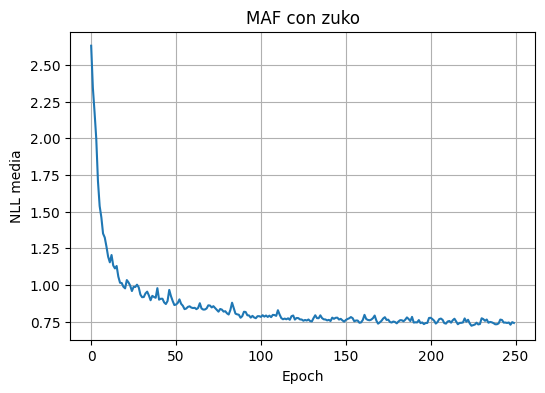

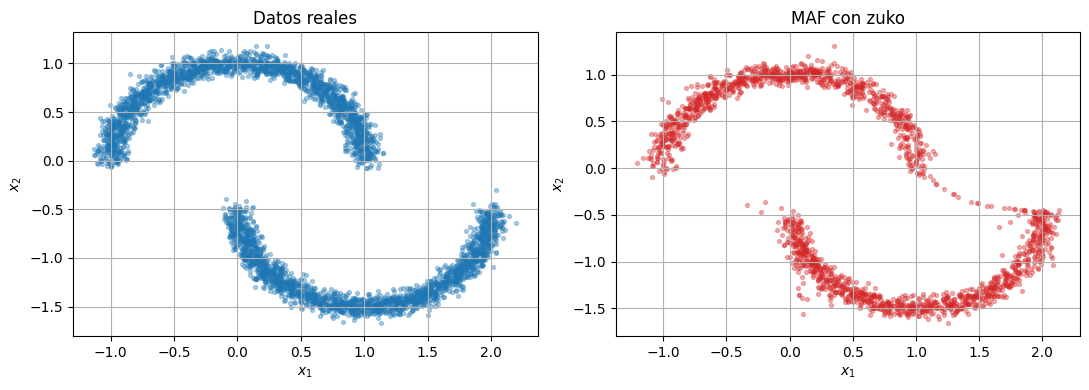

In [11]:
zuko_maf = zuko.flows.MAF(
    features=2,
    transforms=4,
    hidden_features=(64, 64),
)

history_zuko_maf = train_zuko_flow(zuko_maf, train_data, epochs=250, lr=1e-3, verbose_every=50)
plot_history(history_zuko_maf, "MAF con zuko")

with torch.no_grad():
    zuko_maf_samples = standardizer.decode(zuko_maf().sample((2000,)).cpu())

compare_samples(raw_data.cpu(), zuko_maf_samples, title_left="Datos reales", title_right="MAF con zuko")

## Parte 3
### Continuous Normalizing Flows (CNF)

En un CNF no apilamos un numero finito de capas discretas. En cambio, definimos una dinamica continua:

$$
\frac{d x(t)}{dt} = v_\theta(x(t), t).
$$

El dato final $x(1)$ se obtiene integrando una ODE desde $x(0) = z$.

La densidad tambien evoluciona de forma continua:

$$
\frac{d}{dt} \log p(x(t)) = -\operatorname{Tr}\left(\frac{\partial v_\theta}{\partial x(t)}\right).
$$

- los flows discretos deforman el espacio con una secuencia de mapas;
- un CNF lo deforma con un **campo de velocidades**.

Para entender como deforma el espacio un campo vectorial, tomemos un ejemplo simple

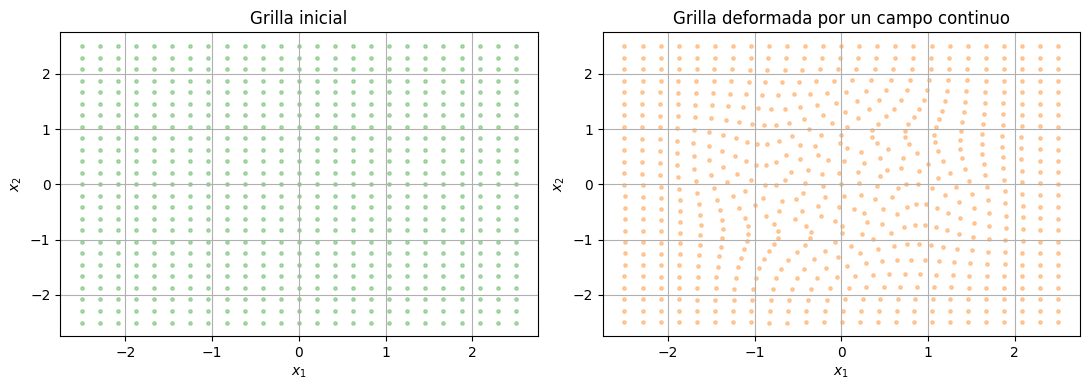

In [46]:
def vector_field(x, t):
    angle = 1.8 * torch.exp(-((x**2).sum(dim=-1, keepdim=True))) # decaimiento exponencial
    rot = torch.cat([-x[:, 1:2], x[:, 0:1]], dim=1) # rotacion 90 grados
    return angle * rot + 0.15 * torch.sin(2 * math.pi * t) * x


def rk4_step(x, t, dt, field):
    k1 = field(x, t)
    k2 = field(x + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = field(x + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = field(x + dt * k3, t + dt)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def integrate_field(x0, steps=80):
    x = x0.clone()
    ts = torch.linspace(0.0, 1.0, steps + 1, device=x0.device)
    dt = 1.0 / steps
    for t in ts[:-1]:
        x = rk4_step(x, t, dt, vector_field)
    return x


grid_1d = torch.linspace(-2.5, 2.5, 25, device=DEVICE)
gx, gy = torch.meshgrid(grid_1d, grid_1d, indexing="xy")
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)
deformed = integrate_field(grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
scatter_2d(grid.cpu(), ax=axes[0], title="Grilla inicial", alpha=0.35, s=6, color="#2ca02c")
scatter_2d(deformed.cpu(), ax=axes[1], title="Grilla deformada por un campo continuo", alpha=0.35, s=6, color="#ff7f0e")
plt.tight_layout()
plt.show()

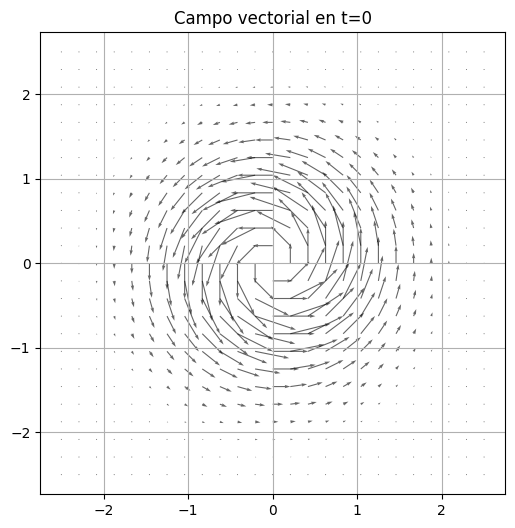

In [47]:
x = grid
t0 = torch.tensor(0.0, device=DEVICE)
v = vector_field(x, t0)

plt.figure(figsize=(6,6))
plt.quiver(
    x[:,0].cpu(),
    x[:,1].cpu(),
    v[:,0].cpu(),
    v[:,1].cpu(),
    alpha=0.6
)
plt.title("Campo vectorial en t=0")
plt.axis("equal")
plt.show()

Para resolverlo, lo haremos unicamente con zuko por su simplicidad

epoch=   1  nll=2.7126
epoch=  30  nll=1.1291
epoch=  60  nll=0.9667
epoch=  90  nll=0.8599
epoch= 120  nll=0.8104
epoch= 150  nll=0.7832
epoch= 180  nll=0.7802


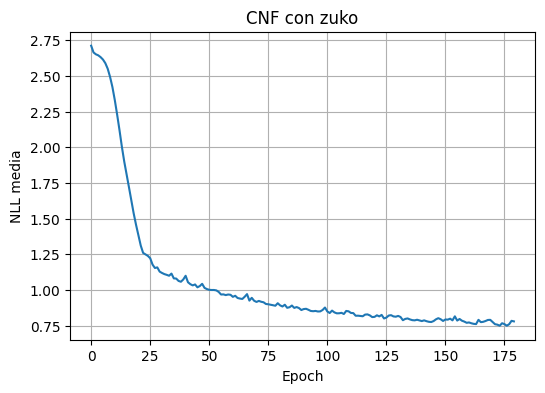

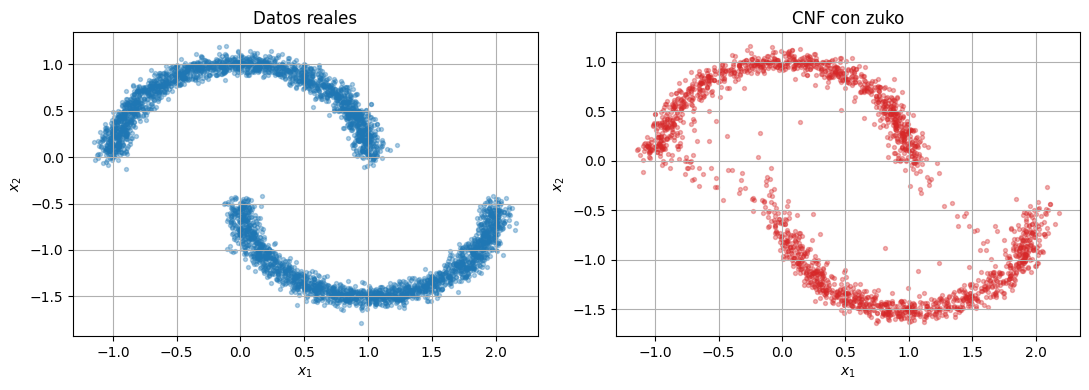

In [48]:
zuko_cnf = zuko.flows.CNF(
    features=2,
    hidden_features=(64, 64),
    atol=1e-5,
    rtol=1e-5,
)

history_cnf = train_zuko_flow(zuko_cnf, train_data, epochs=180, lr=1e-3, verbose_every=30)
plot_history(history_cnf, "CNF con zuko")

with torch.no_grad():
    cnf_samples = standardizer.decode(zuko_cnf().sample((2000,)).cpu())

compare_samples(raw_data.cpu(), cnf_samples, title_left="Datos reales", title_right="CNF con zuko")

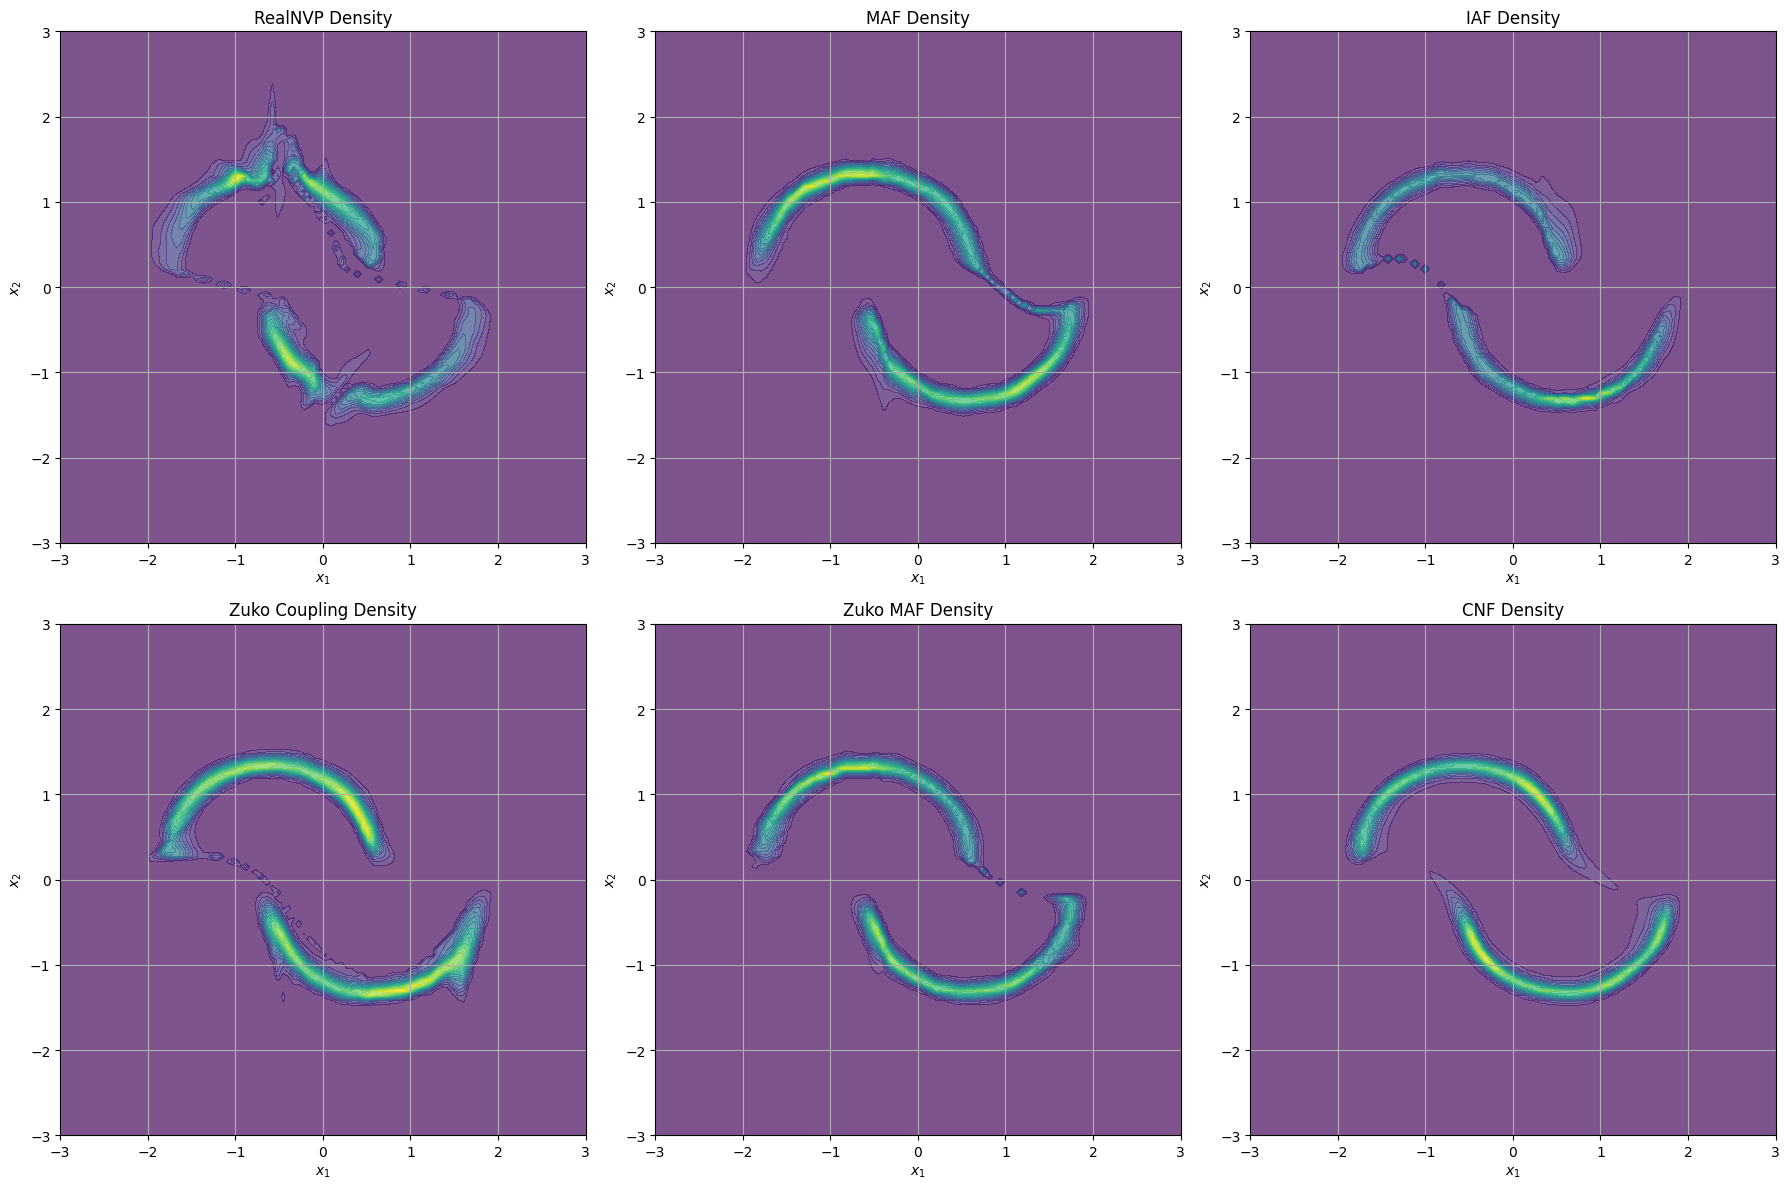

In [ ]:
import numpy as np

# Define a grid for contour plotting
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
grid_points = torch.tensor(np.stack([X1.ravel(), X2.ravel()], axis=1), dtype=torch.float32, device=DEVICE)

# Function to plot contour for a model
def plot_contour(model, title, ax):
    with torch.no_grad():
        log_probs = model.log_prob(grid_points).cpu().numpy().reshape(X1.shape)
    ax.contourf(X1, X2, np.exp(log_probs), levels=20, cmap='viridis', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

# Plot contours for different models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# RealNVP
plot_contour(realnvp, 'RealNVP Density', axes[0, 0])

# MAF
plot_contour(maf, 'MAF Density', axes[0, 1])

# IAF
plot_contour(iaf, 'IAF Density', axes[0, 2])

# Zuko Coupling
with torch.no_grad():
    log_probs_zuko_coupling = zuko_coupling().log_prob(grid_points).cpu().numpy().reshape(X1.shape)
axes[1, 0].contourf(X1, X2, np.exp(log_probs_zuko_coupling), levels=20, cmap='viridis', alpha=0.7)
axes[1, 0].set_title('Zuko Coupling Density')
axes[1, 0].set_xlabel('$x_1$')
axes[1, 0].set_ylabel('$x_2$')

# Zuko MAF
with torch.no_grad():
    log_probs_zuko_maf = zuko_maf().log_prob(grid_points).cpu().numpy().reshape(X1.shape)
axes[1, 1].contourf(X1, X2, np.exp(log_probs_zuko_maf), levels=20, cmap='viridis', alpha=0.7)
axes[1, 1].set_title('Zuko MAF Density')
axes[1, 1].set_xlabel('$x_1$')
axes[1, 1].set_ylabel('$x_2$')

# CNF
with torch.no_grad():
    log_probs_cnf = zuko_cnf().log_prob(grid_points).cpu().numpy().reshape(X1.shape)
axes[1, 2].contourf(X1, X2, np.exp(log_probs_cnf), levels=20, cmap='viridis', alpha=0.7)
axes[1, 2].set_title('CNF Density')
axes[1, 2].set_xlabel('$x_1$')
axes[1, 2].set_ylabel('$x_2$')

plt.tight_layout()
plt.show()